In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 2

intercepto: 5.8660
area: 0.2484


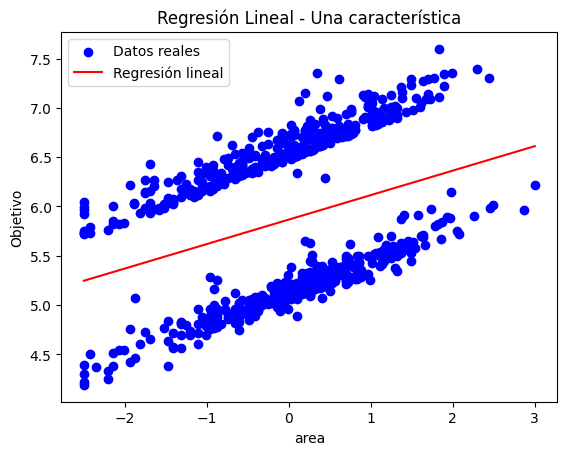

Valores NaN en X: 0
Valores Inf en X: 0
Condición de X: 204.49070407096775
intercepto: 0.0013
area: 0.1521
is_house: 0.0159
has_pool: 0.0126
age: -0.0127
lat: 0.0005
lon: -0.0887
rooms: 0.1213


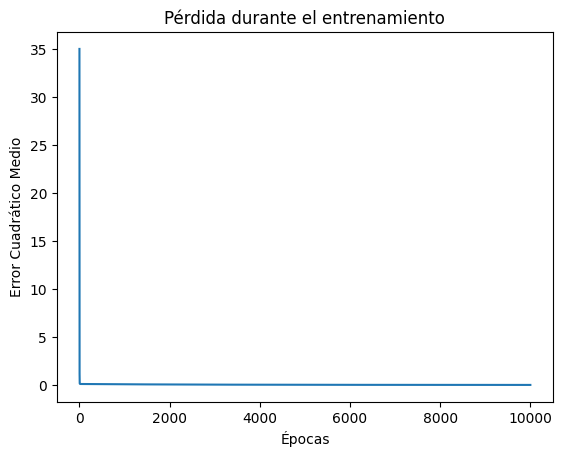

ECM en validación: 0.0302
ECM en prueba: 0.0449


In [ ]:

from Regresion_lineal import RegresionLineal, cargar_datos

# Definir rutas de los archivos
dir_base = ""
train_path = dir_base + "casas_train.csv"
validation_path = dir_base + "casas_validation.csv"
test_path = dir_base + "casas_test_corregido.csv"

# Definir nombres de las características y variable objetivo
features = ["area", "is_house", "has_pool", "age", "lat", "lon", "rooms"]  # Ajusta según el dataset
target = "price"

# Cargar datos de entrenamiento
X_train, y_train = cargar_datos(train_path, features, target)

# Prueba con una característica
X_1 = X_train[:, [0]]  # Solo área
y = y_train
modelo_1 = RegresionLineal(X_1, y)
modelo_1.entrenar_pseudoinversa()
modelo_1.imprimir_coeficientes([features[0]])
modelo_1.graficar_regresion(X_1, y, [features[0]])


# Prueba con múltiples características
modelo_multi = RegresionLineal(X_train, y_train)
modelo_multi.entrenar_descenso_gradiente(lr=0.0001, epochs=10000)
modelo_multi.imprimir_coeficientes(features)
modelo_multi.graficar_perdida()
modelo_multi.graficar_regresion(X_train, y_train, features)


# Validación con el conjunto de validación
X_val, y_val = cargar_datos(validation_path, features, target)
error_val = modelo_multi.calcular_ecm(X_val, y_val)
print(f"ECM en validación: {error_val:.4f}")

# Evaluación en el conjunto de prueba
X_test, y_test = cargar_datos(test_path, features, target)
error_test = modelo_multi.calcular_ecm(X_test, y_test)
print(f"ECM en prueba: {error_test:.4f}")


### 3

Coeficientes (Área -> Precio): [5.86600164 0.24842811]


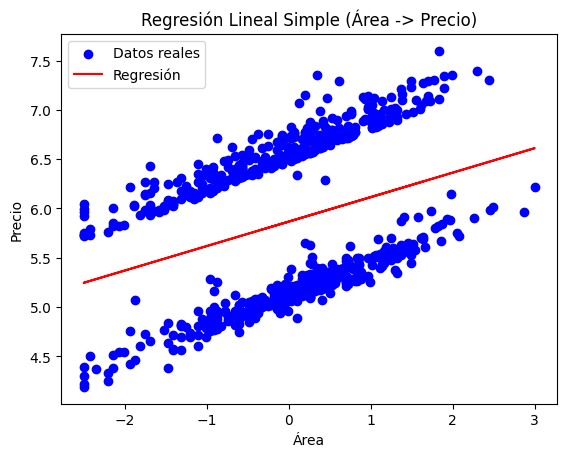

KeyError: 'price'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Función auxiliar para cargar los datos
def cargar_datos(ruta, features, target):
    df = pd.read_csv(ruta)
    X = df[features].values
    y = df[target].values
    return X, y, df

# Rutas de los archivos
ruta_train = 'casas_train.csv'
ruta_test = 'casas_test_corregido.csv'
ruta_amanda = 'vivienda_Amanda.csv'

# 3.1) Regresión lineal simple (Área -> Precio)
X_train, y_train, df_train = cargar_datos(ruta_train, ['area'], 'price')

# Ajustar el modelo por pseudo-inversa
X_train_bias = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
coef_simple = np.linalg.pinv(X_train_bias) @ y_train

print("Coeficientes (Área -> Precio):", coef_simple)

# Graficar la regresión
plt.scatter(X_train, y_train, color='blue', label='Datos reales')
plt.plot(X_train, X_train_bias @ coef_simple, color='red', label='Regresión')
plt.xlabel('Área')
plt.ylabel('Precio')
plt.title('Regresión Lineal Simple (Área -> Precio)')
plt.legend()
plt.show()

# 3.2) Modelo con múltiples características
features = ['area', 'rooms', 'is_house', 'has_pool']
X_train, y_train, df_train = cargar_datos(ruta_train, features, 'price')
X_test, _, df_test = cargar_datos(ruta_test, features, 'price')
X_amanda, _, _ = cargar_datos(ruta_amanda, features, 'price')

X_train_bias = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
coef_multi = np.linalg.pinv(X_train_bias) @ y_train

print("Coeficientes (Modelo Completo):", coef_multi)

# Predicción para vivienda_Amanda
X_amanda_bias = np.hstack((np.ones((X_amanda.shape[0], 1)), X_amanda))
precio_amanda = X_amanda_bias @ coef_multi
print("Predicción para vivienda Amanda:", precio_amanda)

# 3.3) Valor promedio por metro cuadrado
df_casas = pd.read_csv(ruta_train)
df_casas = df_casas[df_casas['is_house'] == 1]  # Solo casas
precio_m2 = df_casas['price'] / df_casas['area']
print("Valor promedio por metro cuadrado de una casa:", precio_m2.mean())

# 3.4) Impacto de una pileta en el precio
# Consideramos el coeficiente asociado a 'has_pool'
impacto_pileta = coef_multi[features.index('has_pool') + 1]
print("Impacto estimado de construir una pileta en el precio:", impacto_pileta)
